# Olist — Ajuste de Hiperparametros (Tuning)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import joblib
from pathlib import Path
from scipy.stats import randint, uniform
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

PASTA = './archive/'

arquivos_treino = ['X_train.csv', 'X_test.csv', 'y_train.csv', 'y_test.csv']
arquivos_faltando = [nome for nome in arquivos_treino if not Path(PASTA, nome).exists()]

if arquivos_faltando:
    raise FileNotFoundError(
        'Arquivos de treino/teste nao encontrados em ./archive/: '
        + ', '.join(arquivos_faltando)
        + '. Execute primeiro o notebook preprocessamento_olist.ipynb para gerar esses arquivos.'
    )

X_train = pd.read_csv(PASTA + 'X_train.csv')
X_test  = pd.read_csv(PASTA + 'X_test.csv')
y_train = pd.read_csv(PASTA + 'y_train.csv').squeeze()
y_test  = pd.read_csv(PASTA + 'y_test.csv').squeeze()

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')

# Tuning usando 100% do dataset de treino.
# Isso consome mais CPU/RAM, mas evita buscar parametros em uma amostra reduzida.
X_sample = X_train
y_sample = y_train
print(f'Tuning com dataset completo: {X_sample.shape[0]:,} linhas ({X_sample.shape[0]/len(X_train)*100:.0f}% do treino)')
print('Buscas configuradas com n_jobs=-1 para usar todos os nucleos disponiveis.\n')

# Dicionarios para acumular resultados
resultados_base  = {}
resultados_tuned = {}

def calc_metricas(y_te, y_pred):
    return {
        'MAE' : round(mean_absolute_error(y_te, y_pred), 3),
        'RMSE': round(np.sqrt(mean_squared_error(y_te, y_pred)), 3),
        'R2'  : round(r2_score(y_te, y_pred), 4),
    }

# Modelos base (parametros default) — treino no dataset completo
print('Treinando modelos base (parametros default, dataset completo)...')
modelos_base = [
    ('Ridge', Ridge(alpha=1.0)),
    ('Random Forest', RandomForestRegressor(
        n_estimators=100, max_depth=20, min_samples_leaf=5,
        random_state=42, n_jobs=-1)),
    ('XGBoost', XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        tree_method='hist', random_state=42, n_jobs=-1, verbosity=0)),
]
for nome, modelo in modelos_base:
    t0 = time.time()
    modelo.fit(X_train, y_train)
    res = calc_metricas(y_test, modelo.predict(X_test))
    resultados_base[nome] = res
    print(f'  {nome:<20s}  MAE={res["MAE"]:.3f}  RMSE={res["RMSE"]:.3f}  R2={res["R2"]:.4f}  ({time.time()-t0:.1f}s)')

print('\nBase pronta. Iniciando tuning no treino completo...')


X_train: (77128, 38)  |  X_test: (19283, 38)
Tuning com dataset completo: 77,128 linhas (100% do treino)
Buscas configuradas com n_jobs=-1 para usar todos os nucleos disponiveis.

Treinando modelos base (parametros default, dataset completo)...
  Ridge                 MAE=4.350  RMSE=6.784  R2=0.4231  (0.1s)
  Random Forest         MAE=3.972  RMSE=6.402  R2=0.4862  (15.0s)
  XGBoost               MAE=3.920  RMSE=6.377  R2=0.4903  (1.0s)

Base pronta. Iniciando tuning no treino completo...


## 1. Ridge — GridSearchCV

=== GridSearchCV — Ridge ===

Grid: 10 valores x 5 folds = 50 modelos
Ridge e rapido — usando dataset completo.

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Tempo: 6.0s
Melhor alpha: 5.0
MAE na validacao cruzada: 4.380 dias

Base:  MAE=4.350  RMSE=6.784  R2=0.4231
Tuned: MAE=4.350  RMSE=6.784  R2=0.4231
Melhora no MAE: +0.000 dias


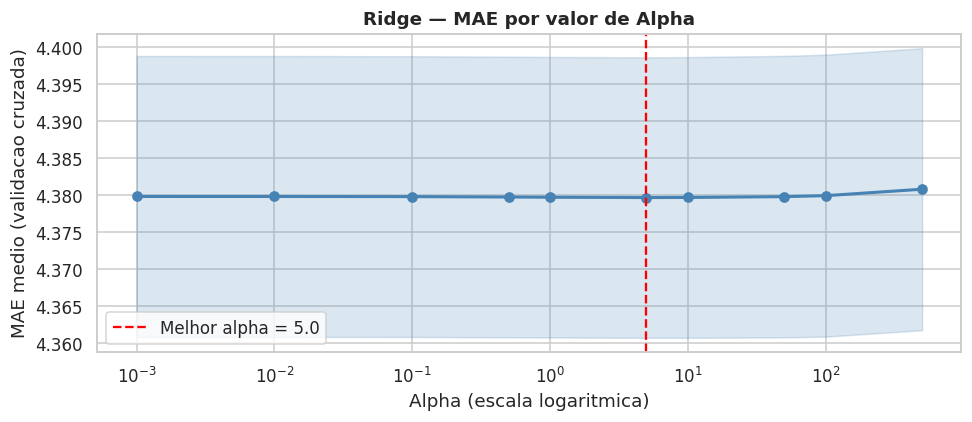

In [2]:
print('=== GridSearchCV — Ridge ===\n')

param_grid_ridge = {
    'alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0]
}
print(f'Grid: {len(param_grid_ridge["alpha"])} valores x 5 folds = {len(param_grid_ridge["alpha"]) * 5} modelos')
print('Ridge e rapido — usando dataset completo.\n')

gs_ridge = GridSearchCV(
    Ridge(),
    param_grid_ridge,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

t0 = time.time()
gs_ridge.fit(X_train, y_train)   # Ridge e rapido, usa treino completo
tempo = time.time() - t0

print(f'\nTempo: {tempo:.1f}s')
print(f'Melhor alpha: {gs_ridge.best_params_["alpha"]}')
print(f'MAE na validacao cruzada: {-gs_ridge.best_score_:.3f} dias')

y_pred_ridge_t = gs_ridge.best_estimator_.predict(X_test)
res = calc_metricas(y_test, y_pred_ridge_t)
resultados_tuned['Ridge'] = res

base = resultados_base['Ridge']
print(f'\nBase:  MAE={base["MAE"]:.3f}  RMSE={base["RMSE"]:.3f}  R2={base["R2"]:.4f}')
print(f'Tuned: MAE={res["MAE"]:.3f}  RMSE={res["RMSE"]:.3f}  R2={res["R2"]:.4f}')
print(f'Melhora no MAE: {base["MAE"] - res["MAE"]:+.3f} dias')

# Curva MAE x alpha
cv_res  = pd.DataFrame(gs_ridge.cv_results_)
mae_cv  = -cv_res['mean_test_score'].values
mae_std =  cv_res['std_test_score'].values
alphas  = param_grid_ridge['alpha']

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(alphas, mae_cv, 'o-', color='steelblue', linewidth=2, markersize=6)
ax.fill_between(alphas, mae_cv - mae_std, mae_cv + mae_std, alpha=0.2, color='steelblue')
ax.axvline(gs_ridge.best_params_['alpha'], color='red', linestyle='--',
           label=f'Melhor alpha = {gs_ridge.best_params_["alpha"]}')
ax.set_xlabel('Alpha (escala logaritmica)')
ax.set_ylabel('MAE medio (validacao cruzada)')
ax.set_title('Ridge — MAE por valor de Alpha', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


## 2. Random Forest — RandomizedSearchCV

=== RandomizedSearchCV — Random Forest ===

Busca no treino completo: 77,128 linhas  |  15 combinacoes x 3 folds = 45 modelos
Estimativa: 2-5 minutos

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Busca concluida em 496.6s (8.3 min)

Retreinando o melhor modelo no dataset completo...
Retreino concluido em 17.4s

Melhores parametros encontrados:
  max_depth                : None
  max_features             : 0.5
  min_samples_leaf         : 9
  min_samples_split        : 9
  n_estimators             : 262
MAE na validacao cruzada (treino completo): 3.987 dias

Base:  MAE=3.972  RMSE=6.402  R2=0.4862
Tuned: MAE=3.942  RMSE=6.388  R2=0.4884
Melhora no MAE: +0.030 dias


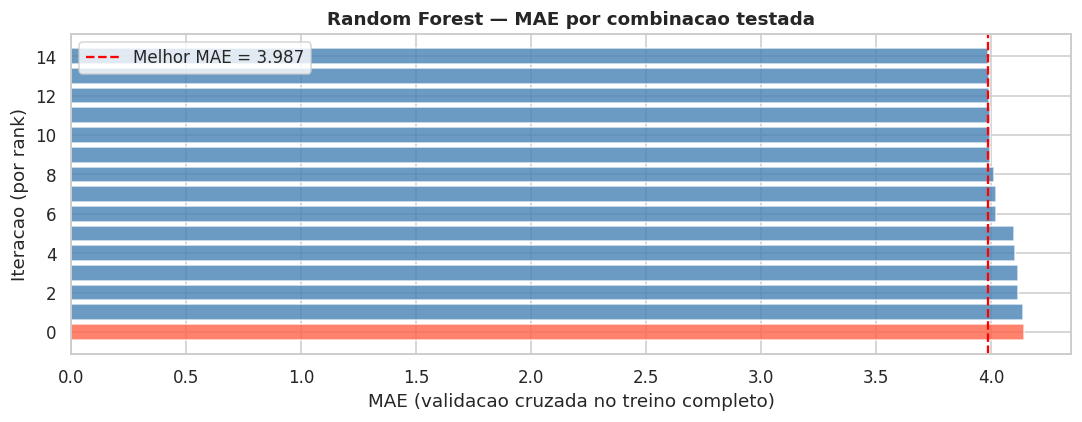

In [3]:
print('=== RandomizedSearchCV — Random Forest ===\n')
print(f'Busca no treino completo: {X_sample.shape[0]:,} linhas  |  15 combinacoes x 3 folds = 45 modelos')
print('Estimativa: 2-5 minutos\n')

param_dist_rf = {
    'n_estimators'     : randint(50, 401),
    'max_depth'        : [10, 15, 20, 25, 30, None],
    'min_samples_leaf' : randint(1, 16),
    'min_samples_split': randint(2, 21),
    'max_features'     : ['sqrt', 'log2', 0.3, 0.5, 0.7],
}

rs_rf = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=1),
    param_distributions=param_dist_rf,
    n_iter=15,
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

t0 = time.time()
rs_rf.fit(X_sample, y_sample)    # busca no treino completo
tempo = time.time() - t0
print(f'\nBusca concluida em {tempo:.1f}s ({tempo/60:.1f} min)')

# Retreina o melhor modelo no dataset COMPLETO
print('\nRetreinando o melhor modelo no dataset completo...')
t0 = time.time()
melhor_rf = RandomForestRegressor(**rs_rf.best_params_, random_state=42, n_jobs=-1)
melhor_rf.fit(X_train, y_train)
print(f'Retreino concluido em {time.time()-t0:.1f}s')

print(f'\nMelhores parametros encontrados:')
for k, v in sorted(rs_rf.best_params_.items()):
    print(f'  {k:<25s}: {v}')
print(f'MAE na validacao cruzada (treino completo): {-rs_rf.best_score_:.3f} dias')

y_pred_rf_t = melhor_rf.predict(X_test)
res = calc_metricas(y_test, y_pred_rf_t)
resultados_tuned['Random Forest'] = res

base = resultados_base['Random Forest']
print(f'\nBase:  MAE={base["MAE"]:.3f}  RMSE={base["RMSE"]:.3f}  R2={base["R2"]:.4f}')
print(f'Tuned: MAE={res["MAE"]:.3f}  RMSE={res["RMSE"]:.3f}  R2={res["R2"]:.4f}')
print(f'Melhora no MAE: {base["MAE"] - res["MAE"]:+.3f} dias')

# Grafico: scores por iteracao
cv_rf = pd.DataFrame(rs_rf.cv_results_).sort_values('rank_test_score')
fig, ax = plt.subplots(figsize=(10, 4))
scores = -cv_rf['mean_test_score'].values
ax.barh(range(len(scores)), scores[::-1],
        color=['tomato' if i == 0 else 'steelblue' for i in range(len(scores))], alpha=0.8)
ax.axvline(-rs_rf.best_score_, color='red', linestyle='--', linewidth=1.5,
           label=f'Melhor MAE = {-rs_rf.best_score_:.3f}')
ax.set_xlabel('MAE (validacao cruzada no treino completo)')
ax.set_ylabel('Iteracao (por rank)')
ax.set_title('Random Forest — MAE por combinacao testada', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


## 3. XGBoost — RandomizedSearchCV

=== RandomizedSearchCV — XGBoost ===

Busca no treino completo: 77,128 linhas  |  20 combinacoes x 3 folds = 60 modelos
Estimativa: 2-5 minutos

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Busca concluida em 41.3s (0.7 min)

Retreinando o melhor modelo no dataset completo...
Retreino concluido em 1.1s

Melhores parametros encontrados:
  colsample_bytree         : 0.8038
  gamma                    : 0.0853
  learning_rate            : 0.0289
  max_depth                : 6
  min_child_weight         : 9
  n_estimators             : 415
  reg_alpha                : 0.5633
  reg_lambda               : 1.2708
  subsample                : 0.5080
MAE na validacao cruzada (treino completo): 3.950 dias

Base:  MAE=3.920  RMSE=6.377  R2=0.4903
Tuned: MAE=3.928  RMSE=6.370  R2=0.4914
Melhora no MAE: -0.008 dias


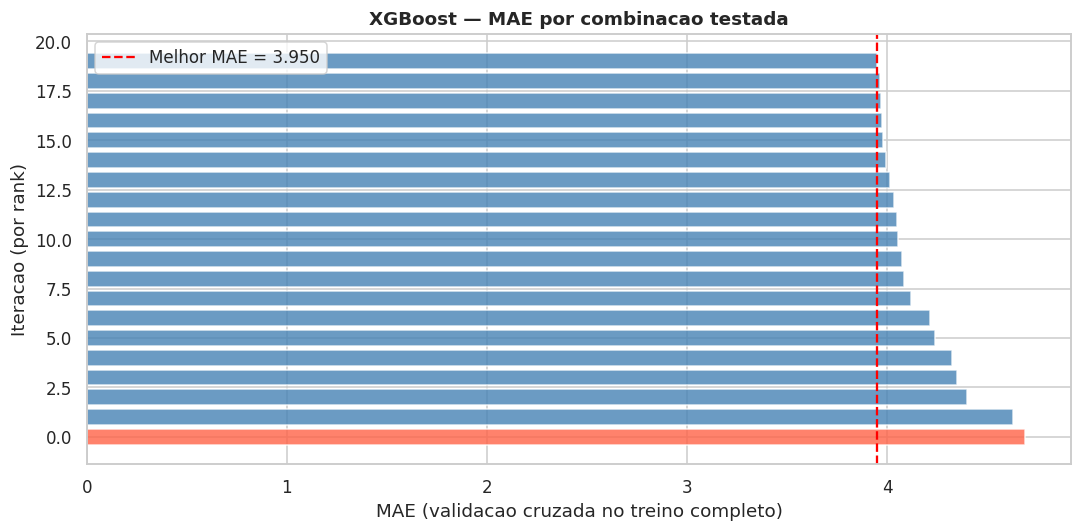

In [4]:
print('=== RandomizedSearchCV — XGBoost ===\n')
print(f'Busca no treino completo: {X_sample.shape[0]:,} linhas  |  20 combinacoes x 3 folds = 60 modelos')
print('Estimativa: 2-5 minutos\n')

param_dist_xgb = {
    'n_estimators'     : randint(100, 601),
    'learning_rate'    : uniform(0.01, 0.29),
    'max_depth'        : randint(3, 11),
    'subsample'        : uniform(0.5, 0.5),
    'colsample_bytree' : uniform(0.5, 0.5),
    'min_child_weight' : randint(1, 11),
    'gamma'            : uniform(0.0, 0.5),
    'reg_alpha'        : uniform(0.0, 1.0),
    'reg_lambda'       : uniform(0.5, 2.0),
}

rs_xgb = RandomizedSearchCV(
    XGBRegressor(tree_method='hist', random_state=42, n_jobs=1, verbosity=0),
    param_distributions=param_dist_xgb,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

t0 = time.time()
rs_xgb.fit(X_sample, y_sample)    # busca no treino completo
tempo = time.time() - t0
print(f'\nBusca concluida em {tempo:.1f}s ({tempo/60:.1f} min)')

# Retreina o melhor modelo no dataset COMPLETO
print('\nRetreinando o melhor modelo no dataset completo...')
t0 = time.time()
melhor_xgb = XGBRegressor(**rs_xgb.best_params_, tree_method='hist', random_state=42, n_jobs=-1, verbosity=0)
melhor_xgb.fit(X_train, y_train)
print(f'Retreino concluido em {time.time()-t0:.1f}s')

print(f'\nMelhores parametros encontrados:')
for k, v in sorted(rs_xgb.best_params_.items()):
    print(f'  {k:<25s}: {v:.4f}' if isinstance(v, float) else f'  {k:<25s}: {v}')
print(f'MAE na validacao cruzada (treino completo): {-rs_xgb.best_score_:.3f} dias')

y_pred_xgb_t = melhor_xgb.predict(X_test)
res = calc_metricas(y_test, y_pred_xgb_t)
resultados_tuned['XGBoost'] = res

base = resultados_base['XGBoost']
print(f'\nBase:  MAE={base["MAE"]:.3f}  RMSE={base["RMSE"]:.3f}  R2={base["R2"]:.4f}')
print(f'Tuned: MAE={res["MAE"]:.3f}  RMSE={res["RMSE"]:.3f}  R2={res["R2"]:.4f}')
print(f'Melhora no MAE: {base["MAE"] - res["MAE"]:+.3f} dias')

# Grafico: scores por iteracao
cv_xgb = pd.DataFrame(rs_xgb.cv_results_).sort_values('rank_test_score')
fig, ax = plt.subplots(figsize=(10, 5))
scores = -cv_xgb['mean_test_score'].values
ax.barh(range(len(scores)), scores[::-1],
        color=['tomato' if i == 0 else 'steelblue' for i in range(len(scores))], alpha=0.8)
ax.axvline(-rs_xgb.best_score_, color='red', linestyle='--', linewidth=1.5,
           label=f'Melhor MAE = {-rs_xgb.best_score_:.3f}')
ax.set_xlabel('MAE (validacao cruzada no treino completo)')
ax.set_ylabel('Iteracao (por rank)')
ax.set_title('XGBoost — MAE por combinacao testada', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


## 4. Comparacao: Antes vs Depois do Tuning

Comparacao Antes vs Depois do Tuning:

               MAE base  MAE tuned  Melhora MAE  RMSE base  RMSE tuned  R2 base  R2 tuned
Modelo                                                                                   
Ridge             4.350      4.350        0.000      6.784       6.784   0.4231    0.4231
Random Forest     3.972      3.942        0.030      6.402       6.388   0.4862    0.4884
XGBoost           3.920      3.928       -0.008      6.377       6.370   0.4903    0.4914


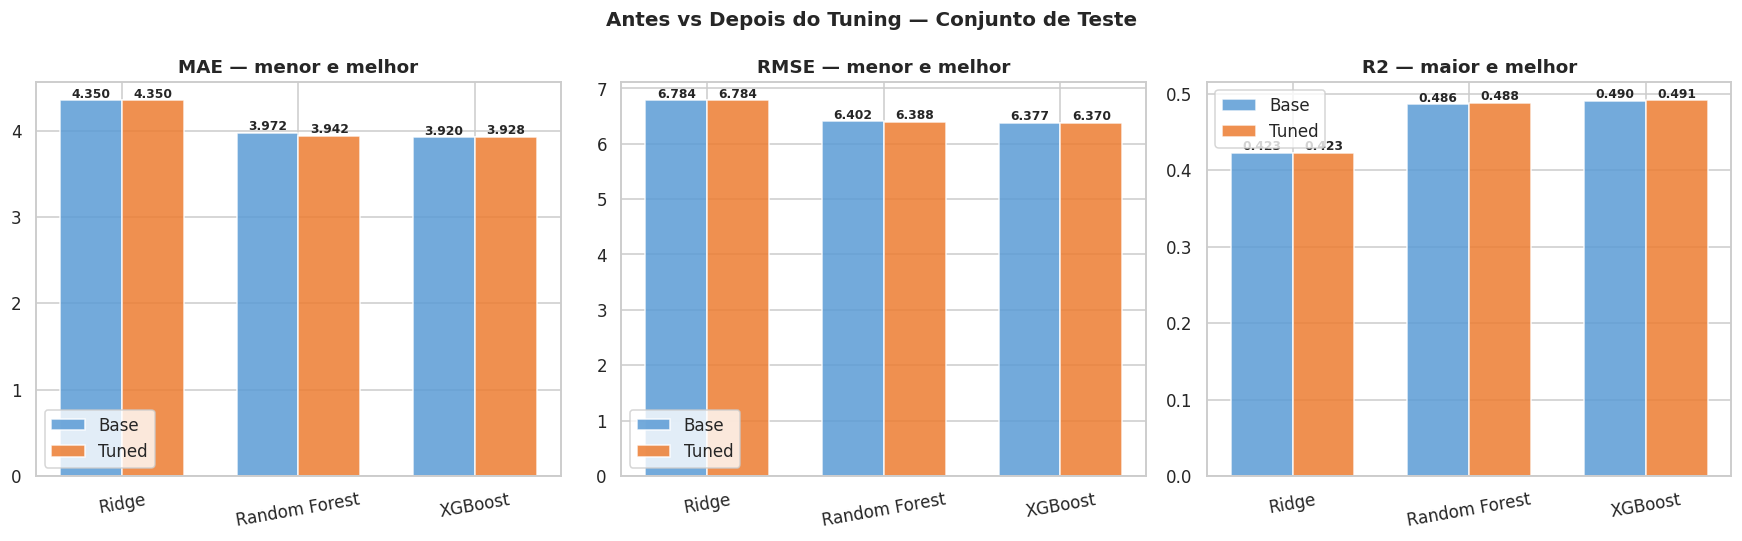

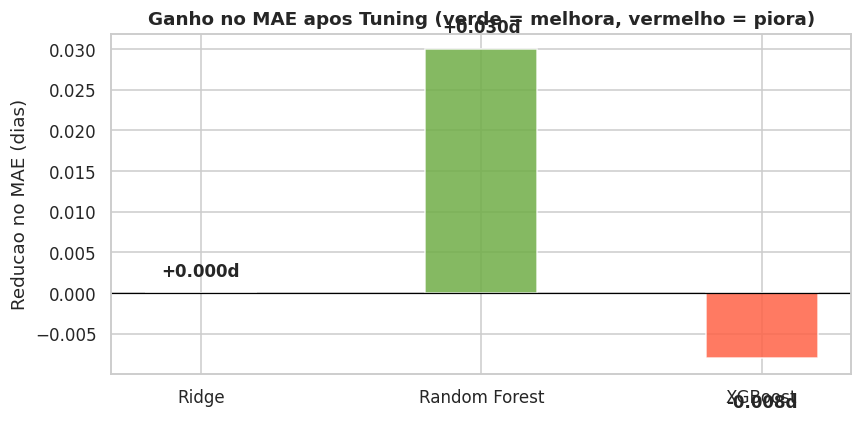


Melhor modelo apos tuning: XGBoost
  MAE  = 3.928 dias
  RMSE = 6.370 dias
  R2   = 0.4914


In [5]:
# Tabela comparativa
rows = []
for nome in ['Ridge', 'Random Forest', 'XGBoost']:
    b = resultados_base[nome]
    t = resultados_tuned[nome]
    rows.append({
        'Modelo'      : nome,
        'MAE base'    : b['MAE'],
        'MAE tuned'   : t['MAE'],
        'Melhora MAE' : round(b['MAE'] - t['MAE'], 3),
        'RMSE base'   : b['RMSE'],
        'RMSE tuned'  : t['RMSE'],
        'R2 base'     : b['R2'],
        'R2 tuned'    : t['R2'],
    })

df_cmp = pd.DataFrame(rows).set_index('Modelo')
print('Comparacao Antes vs Depois do Tuning:\n')
print(df_cmp.to_string())

# Graficos lado a lado
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Antes vs Depois do Tuning — Conjunto de Teste', fontweight='bold', fontsize=13)

modelos = df_cmp.index.tolist()
x = np.arange(len(modelos))
w = 0.35

for ax, m_base, m_tuned, titulo in [
    (axes[0], 'MAE base',  'MAE tuned',  'MAE — menor e melhor'),
    (axes[1], 'RMSE base', 'RMSE tuned', 'RMSE — menor e melhor'),
    (axes[2], 'R2 base',   'R2 tuned',   'R2 — maior e melhor'),
]:
    bars1 = ax.bar(x - w/2, df_cmp[m_base],  width=w, label='Base',  color='#5b9bd5', alpha=0.85)
    bars2 = ax.bar(x + w/2, df_cmp[m_tuned], width=w, label='Tuned', color='#ed7d31', alpha=0.85)
    vmax = max(df_cmp[m_base].max(), df_cmp[m_tuned].max())
    for bar, v in list(zip(bars1, df_cmp[m_base])) + list(zip(bars2, df_cmp[m_tuned])):
        ax.text(bar.get_x() + bar.get_width()/2, v + vmax * 0.008,
                f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(modelos, rotation=10)
    ax.set_title(titulo, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.show()

# Grafico de melhora no MAE
fig, ax = plt.subplots(figsize=(8, 4))
melhoras = df_cmp['Melhora MAE'].values
cores    = ['#70ad47' if v > 0 else 'tomato' for v in melhoras]
bars = ax.bar(modelos, melhoras, color=cores, alpha=0.85, width=0.4)
ax.axhline(0, color='black', linewidth=0.8)
for bar, v in zip(bars, melhoras):
    pos = v + 0.002 if v >= 0 else v - 0.006
    ax.text(bar.get_x() + bar.get_width()/2, pos,
            f'{v:+.3f}d', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Ganho no MAE apos Tuning (verde = melhora, vermelho = piora)', fontweight='bold')
ax.set_ylabel('Reducao no MAE (dias)')
plt.tight_layout()
plt.show()

# Melhor modelo overall
melhor = df_cmp['MAE tuned'].idxmin()
print(f'\nMelhor modelo apos tuning: {melhor}')
print(f'  MAE  = {df_cmp.loc[melhor, "MAE tuned"]:.3f} dias')
print(f'  RMSE = {df_cmp.loc[melhor, "RMSE tuned"]:.3f} dias')
print(f'  R2   = {df_cmp.loc[melhor, "R2 tuned"]:.4f}')

## 5. Modelo Final

In [6]:
# Seleciona o melhor modelo tunado (retreinado no dataset completo)
melhor_nome = df_cmp['MAE tuned'].idxmin()
modelos_tuned_completos = {
    'Ridge'        : gs_ridge.best_estimator_,
    'Random Forest': melhor_rf,
    'XGBoost'      : melhor_xgb,
}
melhor_mod = modelos_tuned_completos[melhor_nome]

joblib.dump(melhor_mod, PASTA + 'modelo_final.pkl')
print(f'Modelo salvo: {PASTA}modelo_final.pkl')

print()
print('=' * 65)
print('  RESUMO DO TUNING')
print('=' * 65)
print(f'\nDataset de treino: {X_train.shape[0]:,} pedidos  |  Teste: {X_test.shape[0]:,}')
print(f'Amostra usada no tuning: {X_sample.shape[0]:,} pedidos (25%)')
print(f'Features: {X_train.shape[1]}')

print(f'\nResultados finais (conjunto de TESTE — modelos retreinados no dataset completo):')
print(f'  {"Modelo":<20s}  {"MAE base":>9s}  {"MAE tuned":>9s}  {"Melhora":>8s}  {"R2 tuned":>9s}')
print('  ' + '-' * 60)
for nome in ['Ridge', 'Random Forest', 'XGBoost']:
    b  = resultados_base[nome]['MAE']
    t  = resultados_tuned[nome]['MAE']
    r2 = resultados_tuned[nome]['R2']
    estrela = ' <-- MELHOR' if nome == melhor_nome else ''
    print(f'  {nome:<20s}  {b:>9.3f}  {t:>9.3f}  {b-t:>+8.3f}  {r2:>9.4f}{estrela}')

buscas = {'Ridge': gs_ridge, 'Random Forest': rs_rf, 'XGBoost': rs_xgb}
print(f'\nMelhores parametros do {melhor_nome}:')
for k, v in sorted(buscas[melhor_nome].best_params_.items()):
    print(f'  {k:<25s}: {v:.4f}' if isinstance(v, float) else f'  {k:<25s}: {v}')

mae_final = resultados_tuned[melhor_nome]['MAE']
r2_final  = resultados_tuned[melhor_nome]['R2']
print(f'\nInterpretacao:')
print(f'  O modelo erra em media {mae_final:.1f} dia(s) por pedido')
print(f'  Explica {r2_final*100:.1f}% da variacao do tempo de entrega')
print(f'  Modelo salvo em: {PASTA}modelo_final.pkl')
print('=' * 65)


Modelo salvo: ./archive/modelo_final.pkl

  RESUMO DO TUNING

Dataset de treino: 77,128 pedidos  |  Teste: 19,283
Amostra usada no tuning: 77,128 pedidos (25%)
Features: 38

Resultados finais (conjunto de TESTE — modelos retreinados no dataset completo):
  Modelo                 MAE base  MAE tuned   Melhora   R2 tuned
  ------------------------------------------------------------
  Ridge                     4.350      4.350    +0.000     0.4231
  Random Forest             3.972      3.942    +0.030     0.4884
  XGBoost                   3.920      3.928    -0.008     0.4914 <-- MELHOR

Melhores parametros do XGBoost:
  colsample_bytree         : 0.8038
  gamma                    : 0.0853
  learning_rate            : 0.0289
  max_depth                : 6
  min_child_weight         : 9
  n_estimators             : 415
  reg_alpha                : 0.5633
  reg_lambda               : 1.2708
  subsample                : 0.5080

Interpretacao:
  O modelo erra em media 3.9 dia(s) por pedido
